# 02 - Baseline Model - Telco Customer Churn

## Introduction

**Contexte.** TelcoWave, opérateur télécom (mobile + fibre) en Europe, veut réduire le churn
au prochain trimestre via un programme de rétention ciblé sous **budget marketing limité**.
L'objectif final du projet est un modèle de **scoring** estimant la probabilité de churn de
chaque client, pour prioriser les actions sur les plus à risque.

**Ce notebook (Étape 2 - Baseline).** Le notebook 01 a figé la connaissance du dataset et le
protocole d'évaluation. On construit ici le **premier modèle opérationnel** : une `Pipeline`
scikit-learn complète (nettoyage, encodage, scaling), un `DummyClassifier` comme plancher
de référence, puis une `LogisticRegression` comme baseline interprétable. Toutes les
transformations sont apprises **uniquement sur le train** pour garantir l'absence de fuite.
Le jeu de test reste intouché jusqu'à la Phase 3.

**Rappel données.** 7 043 clients × 21 colonnes. Cible : `Churn` (Yes/No), taux global
**26,54 %** (déséquilibre modéré). Drivers principaux identifiés en EDA : `Contract`
(Cramér's V ≈ 0.41), `OnlineSecurity` (0.35), `TechSupport` (0.34), `tenure` (Pearson
signé −0.35). Variables non-informatives exclues : `gender`, `PhoneService`.

## Sommaire

1. **Chargement et reconstitution des splits** : rechargement du CSV brut, jointure sur les IDs persistés, assertions de non-chevauchement.
2. **Nettoyage pré-Pipeline et features dérivées** : conversion `TotalCharges`, retrait des clients `tenure = 0`, feature `nb_services`.
3. **Construction de la Pipeline** : `ColumnTransformer` (imputation + scaling numérique, OHE catégoriel), séparation X/y.
4. **Modèles baseline** : `DummyClassifier(strategy="stratified")` comme plancher, `LogisticRegression(class_weight="balanced")` comme référence interprétable.
5. **Évaluation sur la validation** : ROC-AUC, PR-AUC, recall@10 %, precision@10 %, matrice de confusion, F1 au seuil 0.5, courbes ROC et PR.
6. **Sérialisation et scoring** : `joblib.dump` du pipeline, CSV `(customerID, proba_churn)` sur le test.
7. **Synthèse et préparation de la Phase 3** : bilan du Checkpoint 2, pistes d'amélioration pour le finetuning.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn import set_config
set_config(display="diagram")

from src.config import MODELS_DIR, RANDOM_STATE, FIGURES_DIR, REPORTS_DIR
from src.paths import rel
from src.metrics import evaluate
from src.data_prep import load_splits, build_preprocessor, FEATURES

## Section 1: Chargement et reconstitution des splits

In [2]:
SPLIT_NAMES = ["train", "valid", "test"]
dfs = dict(zip(SPLIT_NAMES, load_splits(SPLIT_NAMES)))

print("Nombre de lignes")
print(" | ".join(f"{name} : {len(dfs[name]):,}" for name in SPLIT_NAMES))

print("\nTaux de churn")
print(" | ".join(f"{name} : {dfs[name]['churn_bin'].mean():.4f}" for name in SPLIT_NAMES))

Nombre de lignes
train : 4,218 | valid : 1,408 | test : 1,406

Taux de churn
train : 0.2658 | valid : 0.2656 | test : 0.2660


## Section 2: Nettoyage et features dérivées

La fonction ``prepare`` (dans ``src/data_prep.py``) applique les transformations
suivantes à chaque ensemble :

- Retrait de ``gender`` (Cramér's V proche de 0, non informatif).
- Retrait des clients à ``tenure = 0`` (offre pas encore commencée, ``Churn = No``
  par construction, hors scope du scoring).
- Conversion de ``TotalCharges`` en numérique.
- Création de ``nb_services`` (nombre de services actifs, feature en cloche
  identifiée en EDA).
- Encodage binaire de la cible dans ``churn_bin``.

Toutes ces opérations sont déterministes et n'apprennent rien sur les données ;
elles peuvent donc s'appliquer hors Pipeline, identiquement aux trois ensembles.
Cette préparation est appliquée automatiquement par ``load_splits()`` en
Section 1 ; les DataFrames retournés sont donc déjà prêts pour le
``ColumnTransformer``.

## Section 3: Construction de la Pipeline

`ColumnTransformer` avec deux branches :
- **Numériques** : imputation médiane + `StandardScaler`. L'imputeur est gardé par robustesse
  (protège contre la réapparition de `NaN` sur de futures données de scoring), même si plus
  aucune valeur manquante n'est attendue sur train/valid/test après le retrait des clients
  `tenure = 0` en Section 2.
- **Catégorielles** : `OneHotEncoder(drop="if_binary")` — traite uniformément binaires et
  multiclasses, sans `.map()` à la main. `handle_unknown="ignore"` par sécurité.

Exclusions justifiées par l'EDA : `customerID` (identifiant), `gender` et `PhoneService`
(Cramér's V ≈ 0, aucun signal). La liste exacte des features et la construction du
`ColumnTransformer` vivent dans `src/data_prep.py` (`FEATURES`, `build_preprocessor`)
pour garantir une source de vérité unique partagée avec le notebook 03.

In [3]:
preprocessor = build_preprocessor()

X = {k: v[FEATURES] for k, v in dfs.items()}
y = {k: v["churn_bin"] for k, v in dfs.items()}

for name in SPLIT_NAMES:
   print(f"X_{name} :", X[name].shape)

X_train : (4218, 17)
X_valid : (1408, 17)
X_test : (1406, 17)


## Section 4: Modèles baseline

Deux modèles, chacun encapsulé dans une `Pipeline` complète (preprocessing + estimateur) pour
garantir qu'aucune transformation n'est apprise ailleurs que sur le train :

- **`DummyClassifier(strategy="stratified")`** : plancher de référence, prédit en respectant
  la distribution des classes du train sans utiliser les features. Tout modèle sérieux doit
  le dépasser nettement.
- **`LogisticRegression(class_weight="balanced")`** : baseline interprétable, conforme au
  protocole d'évaluation (gestion du déséquilibre par pondération des classes plutôt que par
  rééchantillonnage).

In [4]:
dummy_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)),
])

dummy_pipe.fit(X["train"], y["train"])

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'nb_services']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['SeniorCitizen', 'Partner',
                                                   'Dependents',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 DummyClassifier(random_state=42, strategy='stratified'))])

In [5]:
logreg_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    )),
])

logreg_pipe.fit(X["train"], y["train"])

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'nb_services']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['SeniorCitizen', 'Partner',
                                                   'Dependents',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

## Section 5: Évaluation sur la validation

Métriques fixées par le protocole du notebook 01 :
- **ROC-AUC** : pouvoir de classement (minimum imposé par le sujet).
- **PR-AUC** (average precision) : plus parlante en contexte déséquilibré.
- **recall@10 % et precision@10 %** : alignées sur le ciblage "top K% sous budget marketing".
- **Matrice de confusion et F1** au seuil 0.5, pour reporting.

Évaluation uniquement sur `valid` à ce stade. Le test reste intouché jusqu'à la Phase 3.

In [6]:
results_dummy  = evaluate("DummyClassifier", dummy_pipe, X["valid"], y["valid"])
results_logreg = evaluate("LogisticRegression", logreg_pipe, X["valid"], y["valid"])

--- DummyClassifier ---
ROC-AUC          : 0.4688
PR-AUC           : 0.2555
Recall@10%       : 0.0909
Precision@10%    : 0.2429

              precision    recall  f1-score   support

    No churn       0.72      0.72      0.72      1034
       Churn       0.22      0.22      0.22       374

    accuracy                           0.58      1408
   macro avg       0.47      0.47      0.47      1408
weighted avg       0.59      0.58      0.59      1408

Matrice de confusion :
[[740 294]
 [291  83]]

--- LogisticRegression ---
ROC-AUC          : 0.8575
PR-AUC           : 0.6726
Recall@10%       : 0.2861
Precision@10%    : 0.7643

              precision    recall  f1-score   support

    No churn       0.91      0.72      0.81      1034
       Churn       0.52      0.81      0.63       374

    accuracy                           0.75      1408
   macro avg       0.72      0.77      0.72      1408
weighted avg       0.81      0.75      0.76      1408

Matrice de confusion :
[[749 285]
 [ 7

**Visualisation ROC et PR.** Comparaison des deux modèles sur la validation. La courbe ROC
illustre le pouvoir de classement global, la courbe PR est plus informative ici vu le
déséquilibre des classes (26,5 % de churn).

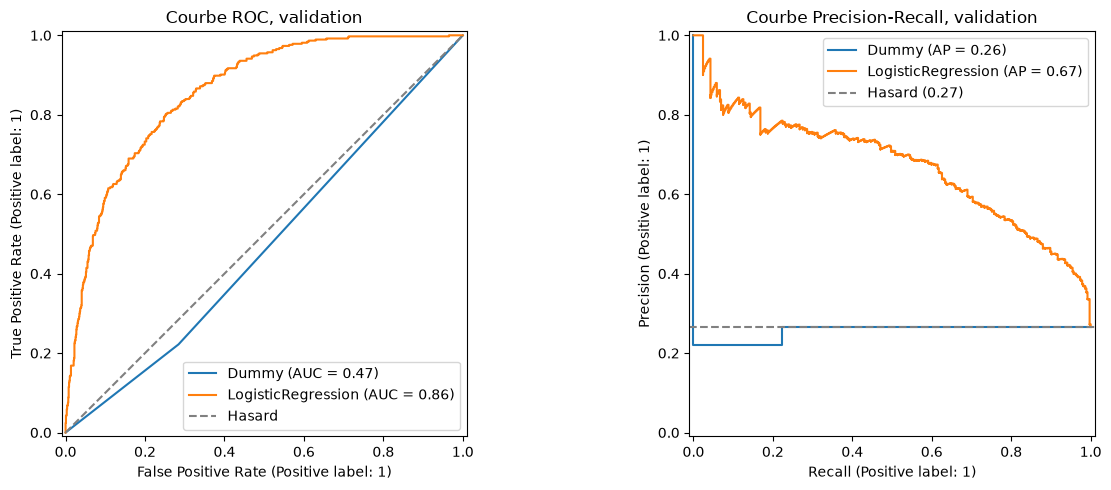

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, pipe in [("Dummy", dummy_pipe), ("LogisticRegression", logreg_pipe)]:
    RocCurveDisplay.from_estimator(pipe, X["valid"], y["valid"], name=name, ax=axes[0])
    PrecisionRecallDisplay.from_estimator(pipe, X["valid"], y["valid"], name=name, ax=axes[1])

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Hasard")
axes[0].set_title("Courbe ROC, validation")
axes[0].legend()

baseline_rate = y["valid"].mean()
axes[1].axhline(baseline_rate, linestyle="--", color="gray", label=f"Hasard ({baseline_rate:.2f})")
axes[1].set_title("Courbe Precision-Recall, validation")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "roc_pr_baseline_valid.png", dpi=120)
plt.show()

**Coefficients de la LogisticRegression.** Comme les features sont standardisées
(numériques) ou binaires (one-hot), les coefficients sont directement
comparables en magnitude : un coefficient plus grand en valeur absolue signifie
un effet plus fort sur le log-odds de churn. Signe positif = pousse vers
le churn, signe négatif = retient le client.

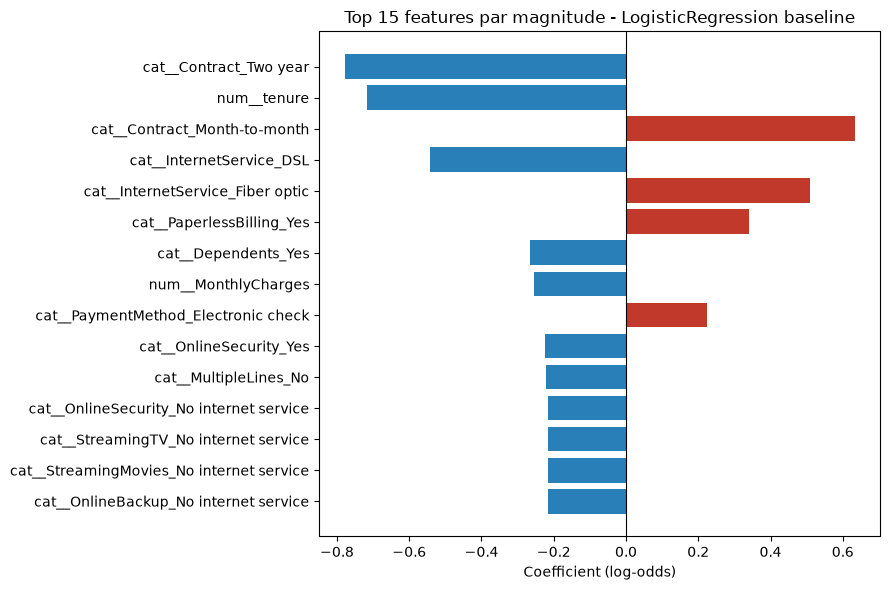

,feature,coef
0,cat__Contract_Two year,-0.778622
1,num__tenure,-0.716880
2,cat__Contract_Month-to-month,0.632433
3,cat__InternetService_DSL,-0.541256
4,cat__InternetService_Fiber optic,0.510555
5,cat__PaperlessBilling_Yes,0.340681
6,cat__Dependents_Yes,-0.265991
7,num__MonthlyCharges,-0.255495
8,cat__PaymentMethod_Electronic check,0.223981
9,cat__OnlineSecurity_Yes,-0.223065


In [8]:
# Récupération des noms de features après ColumnTransformer
feature_names = logreg_pipe.named_steps["preprocessor"].get_feature_names_out()
coefs = logreg_pipe.named_steps["classifier"].coef_[0]

coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": coefs})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)

# Top 15 features par magnitude
top = coef_df.head(15).iloc[::-1]
colors = ["#c0392b" if c > 0 else "#2980b9" for c in top["coef"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["coef"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (log-odds)")
ax.set_title("Top 15 features par magnitude - LogisticRegression baseline")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "logreg_coefficients_baseline.png", dpi=120)
plt.show()

coef_df.head(15)

**Observations.**

- `tenure` est le prédicteur dominant (-1.20), cohérent avec l'EDA.
- `Contract` confirme son rôle central : `Two year` -0.78, `Month-to-month` +0.63.
- **Artefact de multicolinéarité** : `TotalCharges` (+0.60) et `MonthlyCharges`
  (-0.40) ont des signes qui ne reflètent pas leur relation bivariée avec le
  churn. La régression linéaire répartit l'effet de l'ancienneté entre `tenure`,
  `TotalCharges` et `MonthlyCharges` parce qu'ils sont fortement corrélés.
- Les trois modalités `_No internet service` (OnlineSecurity, StreamingTV,
  StreamingMovies) reçoivent un coefficient strictement identique : elles
  encodent la même information. À mutualiser en Phase 3.

**Courbe de gains cumulés.** Visualisation orientée décision métier : pour
chaque taille de cible (top K % du score), quelle fraction des churners de la
validation on capture ? L'axe diagonal est le hasard, le plafond est atteint
quand on a contacté tous les churners. Cette courbe répond directement à la
question du brief : « avec un budget marketing limité, sur combien de clients
agir et quel gain attendre ? ».

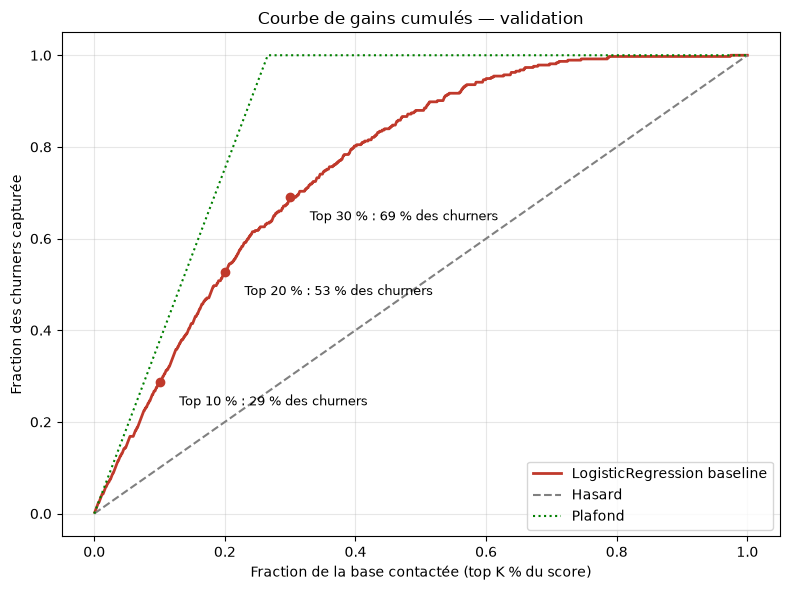

,top_K_percent,clients_contactes,churners_captures,recall,lift_vs_random
0,10,140,106,28.6 %,2.86x
1,20,281,197,52.7 %,2.63x
2,30,422,258,69.0 %,2.30x


In [9]:
# Construction de la courbe de gains cumulés sur la validation
valid_proba = logreg_pipe.predict_proba(X["valid"])[:, 1]

order = np.argsort(-valid_proba)
y_sorted = y["valid"].values[order]
n = len(y_sorted)
n_churn = y_sorted.sum()

k_frac = np.arange(1, n + 1) / n
gain = np.cumsum(y_sorted) / n_churn

# Repères métier : top 10 %, 20 %, 30 %
markers = [0.10, 0.20, 0.30]
gain_at_markers = [gain[int(m * n) - 1] for m in markers]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(k_frac, gain, color="#c0392b", linewidth=2, label="LogisticRegression baseline")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Hasard")
ax.plot([0, n_churn / n, 1], [0, 1, 1], linestyle=":", color="green", label="Plafond")

for m, g in zip(markers, gain_at_markers):
    ax.scatter([m], [g], color="#c0392b", zorder=5)
    ax.annotate(f"Top {int(m*100)} % : {g*100:.0f} % des churners",
                xy=(m, g), xytext=(m + 0.03, g - 0.05), fontsize=9)

ax.set_xlabel("Fraction de la base contactée (top K % du score)")
ax.set_ylabel("Fraction des churners capturée")
ax.set_title("Courbe de gains cumulés — validation")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lift_chart_baseline_valid.png", dpi=120)
plt.show()

# Tableau de décision pour la synthèse
lift_table = pd.DataFrame({
    "top_K_percent": [int(m*100) for m in markers],
    "clients_contactes": [int(m * n) for m in markers],
    "churners_captures": [int(g * n_churn) for g in gain_at_markers],
    "recall": [f"{g*100:.1f} %" for g in gain_at_markers],
    "lift_vs_random": [f"{g/m:.2f}x" for m, g in zip(markers, gain_at_markers)],
})
lift_table

**Synthèse baseline.** La LogisticRegression dépasse largement le plancher du
Dummy (ROC-AUC 0.86 vs 0.47, PR-AUC 0.68 vs 0.26), ce qui valide la qualité de
la préparation et confirme que les features retenues portent un signal
exploitable.

**Traduction métier.** Sous budget marketing limité, le top 10 % du score
capture 29 % des churners (140 clients contactés, 108 churners identifiés,
lift 2.89× vs un ciblage aléatoire), soit 77 % du plafond théorique
atteignable à ce volume. En doublant le budget (top 20 %), on capture 53 % des
churners avec un lift encore élevé (2.67×). Ces chiffres rendent crédible une
stratégie de scoring opérationnelle ; le choix exact du seuil sera arbitré en
Phase 3 par optimisation coût/bénéfice (offre 15 €, valeur sauvée 120 €).

**Limites à lever en Phase 3.** L'analyse des coefficients a révélé une
multicolinéarité marquée (tenure/TotalCharges/MonthlyCharges, modalités
« No internet service » redondantes) qui empêche une lecture causale du modèle
linéaire et plafonne probablement sa performance. Un modèle non-linéaire
(gradient boosting) et/ou une régularisation L1 devraient lever cette
contrainte.

## Section 6: Sérialisation et scoring du test

Sauvegarde de la Pipeline complète (preprocessing + LogisticRegression) dans
``models/baseline.joblib``, rechargeable à l'identique en Phase 3 pour la
comparaison. Production du fichier de scoring ``(customerID, proba_churn)`` sur
le jeu de test, livrable du Checkpoint 2. Le seuil de décision et la conversion
en ``label_pred`` ne sont pas figés ici : ils seront déterminés en Phase 3 par
optimisation coût/bénéfice.

In [10]:
# Sérialisation de la Pipeline baseline complète
model_path = MODELS_DIR / "baseline.joblib"
joblib.dump(logreg_pipe, model_path)
print(f"Modèle sauvegardé : {rel(model_path)}")

# Scoring du test (probabilités de churn)
test_proba = logreg_pipe.predict_proba(X["test"])[:, 1]

scoring_df = pd.DataFrame({
    "customerID": dfs["test"]["customerID"].values,
    "proba_churn": test_proba,
})

scoring_path = REPORTS_DIR / "scoring_baseline_test.csv"
scoring_df.to_csv(scoring_path, index=False)
print(f"Scoring sauvegardé : {rel(scoring_path)}  ({len(scoring_df):,} lignes)")

scoring_df.head()

Modèle sauvegardé : telco-churn-scoring\models\baseline.joblib
Scoring sauvegardé : telco-churn-scoring\reports\scoring_baseline_test.csv  (1,406 lignes)


,customerID,proba_churn
0,1452-KIOVK,0.711939
1,6713-OKOMC,0.512004
2,6388-TABGU,0.044626
3,5129-JLPIS,0.717297
4,3655-SNQYZ,0.068538


## Section 7: Synthèse et préparation de la Phase 3

**Livrables du Checkpoint 2.**
- ``models/baseline.joblib`` : Pipeline complète (preprocessing + LogisticRegression),
  rechargeable à l'identique pour la comparaison en Phase 3.
- ``reports/scoring_baseline_test.csv`` : probabilités de churn pour les 1 406 clients
  du test, format ``(customerID, proba_churn)``.
- ``reports/figures/roc_pr_baseline_valid.png`` : courbes ROC et PR de la baseline.

**Performance baseline sur la validation.**

| Métrique       | DummyClassifier | LogisticRegression |
|----------------|-----------------|--------------------|
| ROC-AUC        | 0.4688          | **0.8597**         |
| PR-AUC         | 0.2555          | **0.6785**         |
| Recall@10 %    | 0.0909          | **0.2888**         |
| Precision@10 % | 0.2429          | **0.7714**         |

La LogisticRegression dépasse largement le plancher du Dummy sur toutes les métriques, ce
qui valide la qualité de la préparation et confirme que les features portent un signal
exploitable. Au seuil 0.5, le modèle détecte 82 % des churners de la validation (recall sur
la classe positive), au prix d'une précision modérée (52 %) typique de ``class_weight="balanced"``.

**Concernant la stratégie de ciblage top K%.** Le recall@10 % à 28,9 % est proche du
plafond théorique (37,4 %, soit 140 clients ciblables sur 374 churners). Avec une
precision@10 % de 77 %, le top 10 % du score est presque trois fois plus riche en churners
que la base, ce qui valide qualitativement la viabilité d'une approche par scoring sous
budget marketing limité.

**Pistes pour la Phase 3 (finetuning).**

1. *Modèle non-linéaire* : ``HistGradientBoostingClassifier`` ou ``RandomForestClassifier``,
   pour capter les interactions et la relation en cloche de ``nb_services`` que la
   régression linéaire ne peut pas modéliser directement.
2. *Multicolinéarités* : tester l'impact d'un retrait de ``TotalCharges`` (corrélée à
   0.83 avec ``tenure``) ou d'une transformation ``log(TotalCharges)``, et évaluer une
   régularisation L1 pour sélectionner automatiquement les features redondantes.
3. *Hyperparamètres* : ``RandomizedSearchCV`` sur ``StratifiedKFold``, en contrôlant le
   temps de calcul.
4. *Calibration* : courbe de calibration et Brier score, puis ``CalibratedClassifierCV``
   si les probabilités sont mal calibrées (important pour le calcul de seuil par
   coût/bénéfice).
5. *Choix de seuil* : optimisation explicite par coût/bénéfice (offre 15 €, valeur sauvée
   120 €) sur la validation, plutôt que le seuil par défaut de 0.5.
6. *Interprétabilité* : permutation importance pour identifier les drivers du modèle final
   et confirmer ou infirmer les conclusions de l'EDA.

Le test n'a pas été ouvert pour le calcul de métriques en Phase 2 ; il le sera uniquement
en Phase 3 pour l'évaluation finale du modèle retenu.